In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_df= pd.read_csv("../data/raw/train.csv.zip")
stores = pd.read_csv("../data/raw/stores.csv")
features = pd.read_csv("../data/raw/features.csv.zip")

In [3]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


## Final dataset

I will combine these 3 data sources to create a single, more complete dataset for the retail analysis:
- `train.csv` → sales data (core fact table)
- `features.csv` → external factors (CPI, unemployment, fuel price, promotions)
- `stores.csv` → store characteristics (type, size)

I use **left joins** to keep all sales records in `train.csv` and enrich them with additional context.

This final dataset will be used for EDA, statistical analysis, and forecasting models.

In [7]:
df= train_df.merge(features, on=["Store", "Date"], how="left")

In [8]:
df=df.merge(stores, on="Store", how="left")

In [9]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## Data Dictionary

| Feature | Description |
|---|---|
| Store | Unique store identifier |
| Dept | Department identifier within the store |
| Date | Week of recorded sales |
| Weekly_Sales | Weekly sales amount |
| IsHoliday | Indicates whether the week includes a holiday |
| Temperature | Average temperature for the week |
| Fuel_Price | Regional fuel price |
| CPI | Consumer Price Index |
| Unemployment | Regional unemployment rate |
| MarkDown1-5 | Promotional and markdown activity variables |
| Type | Store category (A, B, C) |
| Size | Store size |

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  IsHoliday_y   421570 non-null  bool   
 15  Type          421570 non-null  object 
 16  Size          421570 non-null  int64  
dtypes: bool(2), float64(10), int64(3), object(2)
mem

In [21]:
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


In [23]:
df.isna().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [25]:
df[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].isnull().mean() * 100

MarkDown1    64.257181
MarkDown2    73.611025
MarkDown3    67.480845
MarkDown4    67.984676
MarkDown5    64.079038
dtype: float64

**NaN** values in MarkDown 1-5 -> periods where no promotional campaigns or markdown activities were active.

In [29]:
df.duplicated().sum()

0

## EDA

**Weekly sales distributions**

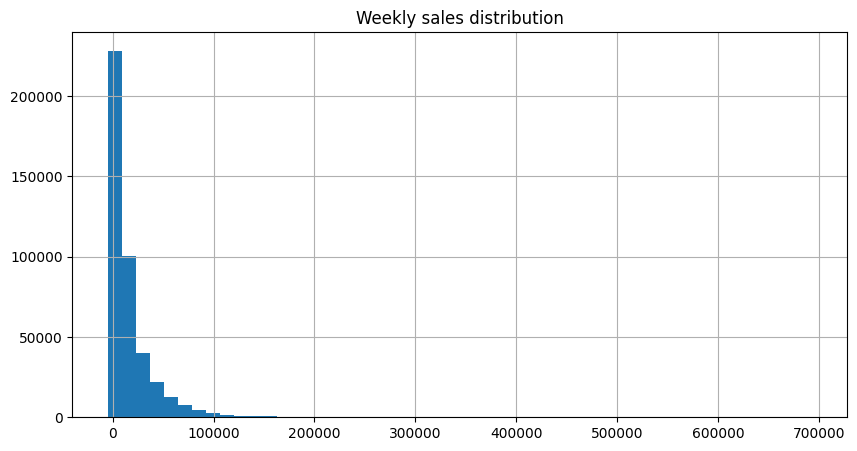

In [37]:
df['Weekly_Sales'].hist(bins=50, figsize=(10,5))
plt.title("Weekly sales distribution")
plt.show()

Logarithmic scale (`yscale = "log"`) to better visualize the distribution of Weekly Sales.

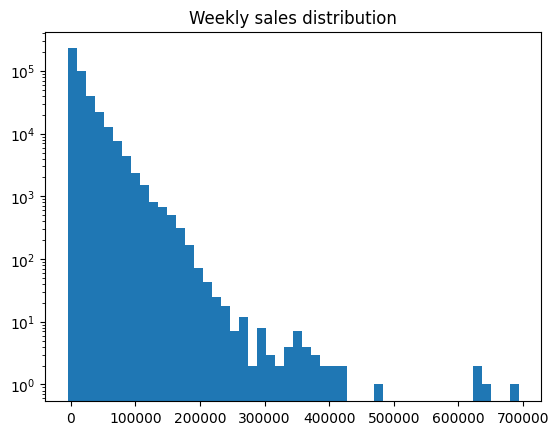

In [42]:
plt.hist(df["Weekly_Sales"], bins=50)
plt.yscale("log")
plt.title("Weekly sales distribution")
plt.show()

## Holiday effect

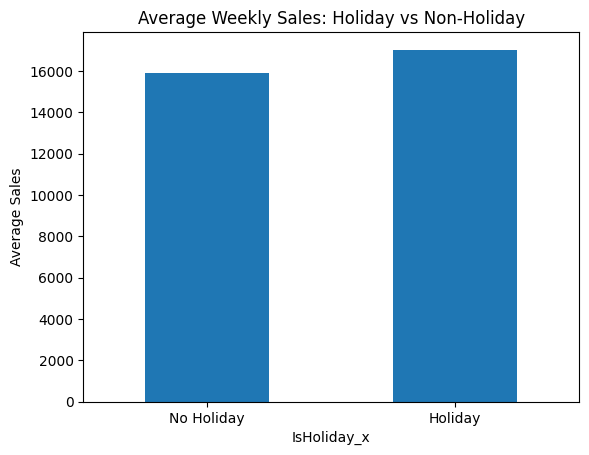

In [51]:
df.groupby("IsHoliday_x")["Weekly_Sales"].mean().plot(kind='bar')
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Sales")
plt.xticks([0,1], ["No Holiday", "Holiday"], rotation=0)
plt.show()

Holiday effect isn't strong, let's use a boxplot to explore better

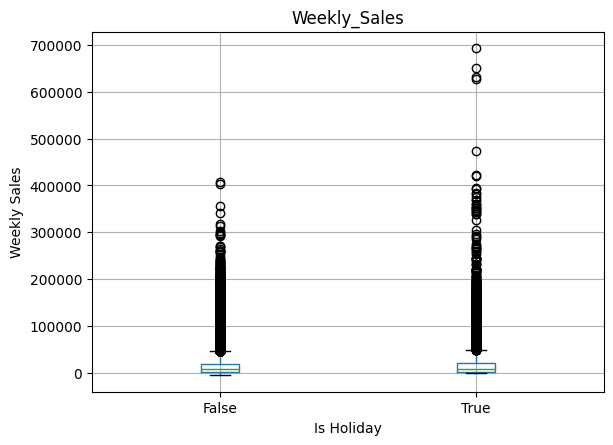

In [62]:
df.boxplot(column='Weekly_Sales',  by='IsHoliday_x')
plt.suptitle("")  # to remove automatic title
plt.xlabel("Is Holiday")
plt.ylabel("Weekly Sales")
plt.show();

## Holiday Effect by Store

After analyzing holiday impact globally, we now investigate whether
specific stores experience stronger holiday effects.

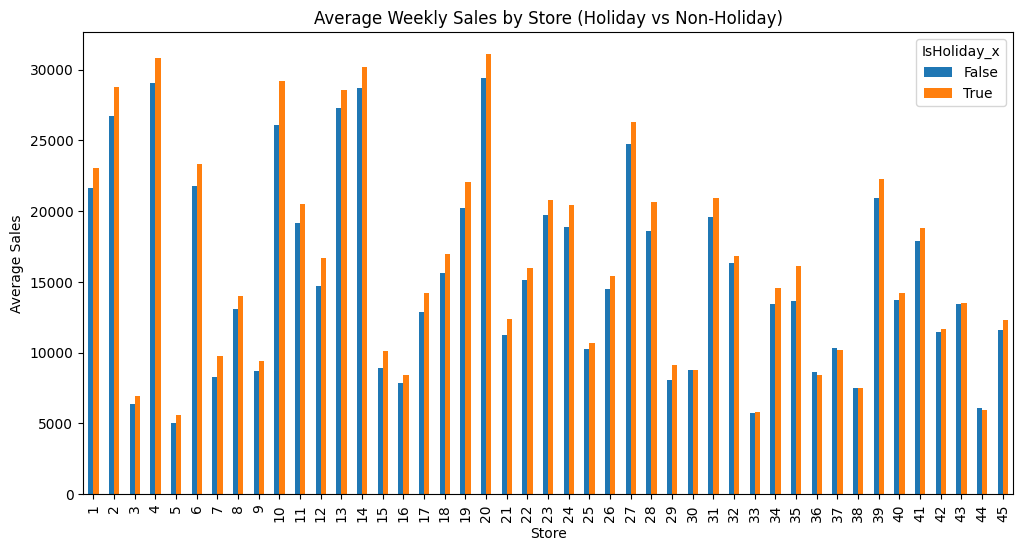

In [75]:
df.groupby(["Store", "IsHoliday_x"])["Weekly_Sales"].mean().unstack().plot(kind="bar", figsize=(12,6))
plt.title("Average Weekly Sales by Store (Holiday vs Non-Holiday)")
plt.ylabel("Average Sales")
plt.xlabel("Store")
plt.xticks(rotation=90)
plt.show()

At store level, holiday weeks show slightly higher average sales compared to non-holiday weeks.
However, the difference is not visually strong, suggesting that holiday impact is relatively weak when aggregated at store level.

This indicates that sales variation is likely driven more by internal store dynamics and temporal factors than by holidays alone.

## Holiday Effect by Department

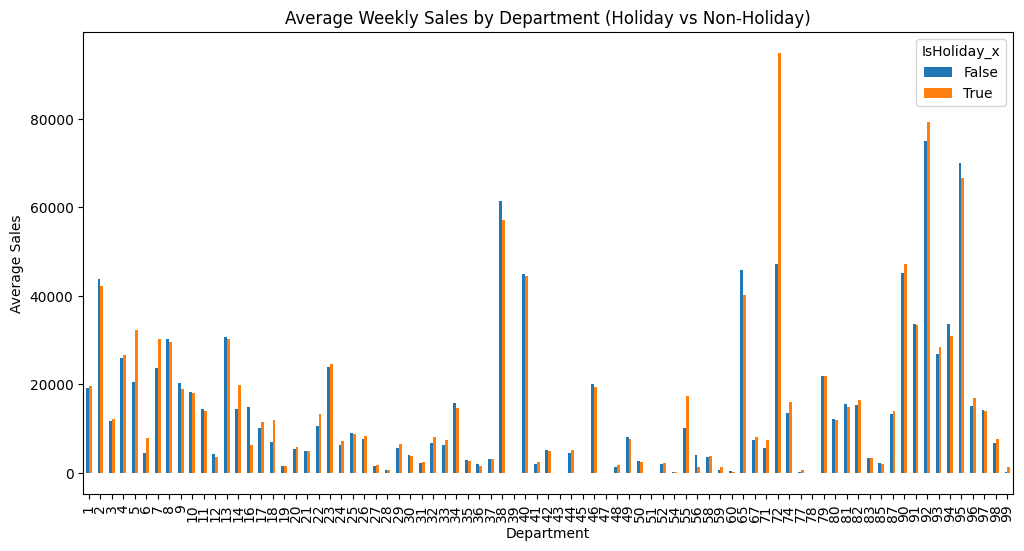

In [80]:
df.groupby(["Dept", "IsHoliday_x"])["Weekly_Sales"].mean().unstack().plot(kind="bar", figsize=(12,6))
plt.title("Average Weekly Sales by Department (Holiday vs Non-Holiday)")
plt.ylabel("Average Sales")
plt.xlabel("Department")
plt.xticks(rotation=90)
plt.show()

While most departments show minimal differences between holiday and non-holiday sales,
a small number of departments exhibit a significantly higher sales increase during holidays.

This suggests that the holiday effect is highly concentrated and not uniformly distributed
across product categories.

## Holiday Lift by Department

In [95]:
dept_holiday = df.groupby(["Dept", "IsHoliday_x"])["Weekly_Sales"].mean().unstack()

dept_holiday["Holiday_Lift_%"] = (
    (dept_holiday[True] - dept_holiday[False])
    / dept_holiday[False]
) * 100

dept_holiday.sort_values("Holiday_Lift_%", ascending=False).head(10)

IsHoliday_x,False,True,Holiday_Lift_%
Dept,,,
99,311.443638,1255.500842,303.122970
77,191.839706,620.346250,223.366973
59,647.219559,1310.373333,102.461949
72,47217.852117,94855.542259,100.889151
6,4513.898625,7832.547844,73.520686
18,6908.599161,11906.612807,72.344820
55,10224.378094,17269.993274,68.909963
5,20538.617153,32386.823702,57.687460
14,14496.807073,19847.280267,36.907942


Certain departments (e.g., 99, 77, 59) show extremely high holiday lift percentages.

However, these results should be interpreted carefully, as **percentage changes are highly sensitive to baseline sales levels** (the samller the base line -> the bigger the holiday lift %).

Further analysis is required to evaluate the actual business impact of these departments in terms of total sales and revenue contribution.

## Department Contribution - Total Sales

<Figure size 1200x600 with 0 Axes>

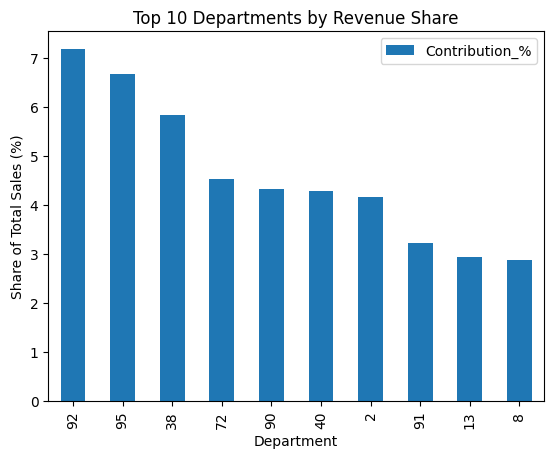

In [93]:
dept_contribution = df.groupby("Dept")["Weekly_Sales"].sum().reset_index()
dept_contribution["Contribution_%"] = dept_contribution["Weekly_Sales"] / dept_contribution["Weekly_Sales"].sum() * 100


plt.figure(figsize=(12,6))
dept_contribution.sort_values("Contribution_%", ascending=False).head(10).plot(
    x="Dept",
    y="Contribution_%",
    kind="bar"
)

plt.title("Top 10 Departments by Revenue Share")
plt.ylabel("Share of Total Sales (%)")
plt.xlabel("Department")

plt.show();

The top 10-performing departments contribute a significant portion of total sales,
but no single department dominates the business.

This indicates a **multi-driver structure**, where overall performance is driven by
a combination of key departments rather than a single dominant category.